# SECOM — Exploratory Data Analysis

The SECOM (Semiconductor Manufacturing) dataset, consists of manufacturing operation data and the semiconductor quality data. It contains 1567 records, 590 anonymized features and 104 fails, which makes it an imbalanced dataset with 14:1 ratio of pass to fails.

Goal of this notebook is to characterise the dataset.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src.data import load_secom

df = load_secom()
print(df.shape)
df.head()

(1567, 592)


,timestamp,fail,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_580,sensor_581,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589
0,2008-07-19 11:55:00,0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,2008-07-19 12:32:00,0,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2008-07-19 13:17:00,1,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2008-07-19 14:43:00,0,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,2008-07-19 15:22:00,0,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


## Class balance

In [2]:
counts = df['fail'].value_counts().sort_index()
pct = df['fail'].value_counts(normalize=True).sort_index()
summary_table = pd.DataFrame({
    'Count': counts,
    'Percentage': pct.round(4)*100
})
summary_table.index = ['Pass (0)', 'Fail (1)']
print(summary_table)

          Count  Percentage
Pass (0)   1463       93.36
Fail (1)    104        6.64


The dataset is heavily imbalanced in favor of "pass". 
If we classified every single datapoint as Pass, our accuracy would be 93.36% but we would be missing all defects. Therefore, accuracy is a misleading metric here.

## Missing values

In [3]:
sensor_cols = [c for c in df.columns if c.startswith('sensor_')]

missing_frac = df[sensor_cols].isna().mean()  # fraction missing per column

print(f'Overall missing rate: {df[sensor_cols].isna().mean().mean():.2%}')
print(f'Columns with any missing:   {(missing_frac > 0).sum()} out of {len(sensor_cols)} ({(missing_frac > 0).sum() / len(sensor_cols):.2%})')
print(f'Columns >50% missing:        {(missing_frac > 0.50).sum()} out of {len(sensor_cols)} ({(missing_frac > 0.50).sum() / len(sensor_cols):.2%})')


Overall missing rate: 4.54%
Columns with any missing:   538 out of 590 (91.19%)
Columns >50% missing:        28 out of 590 (4.75%)


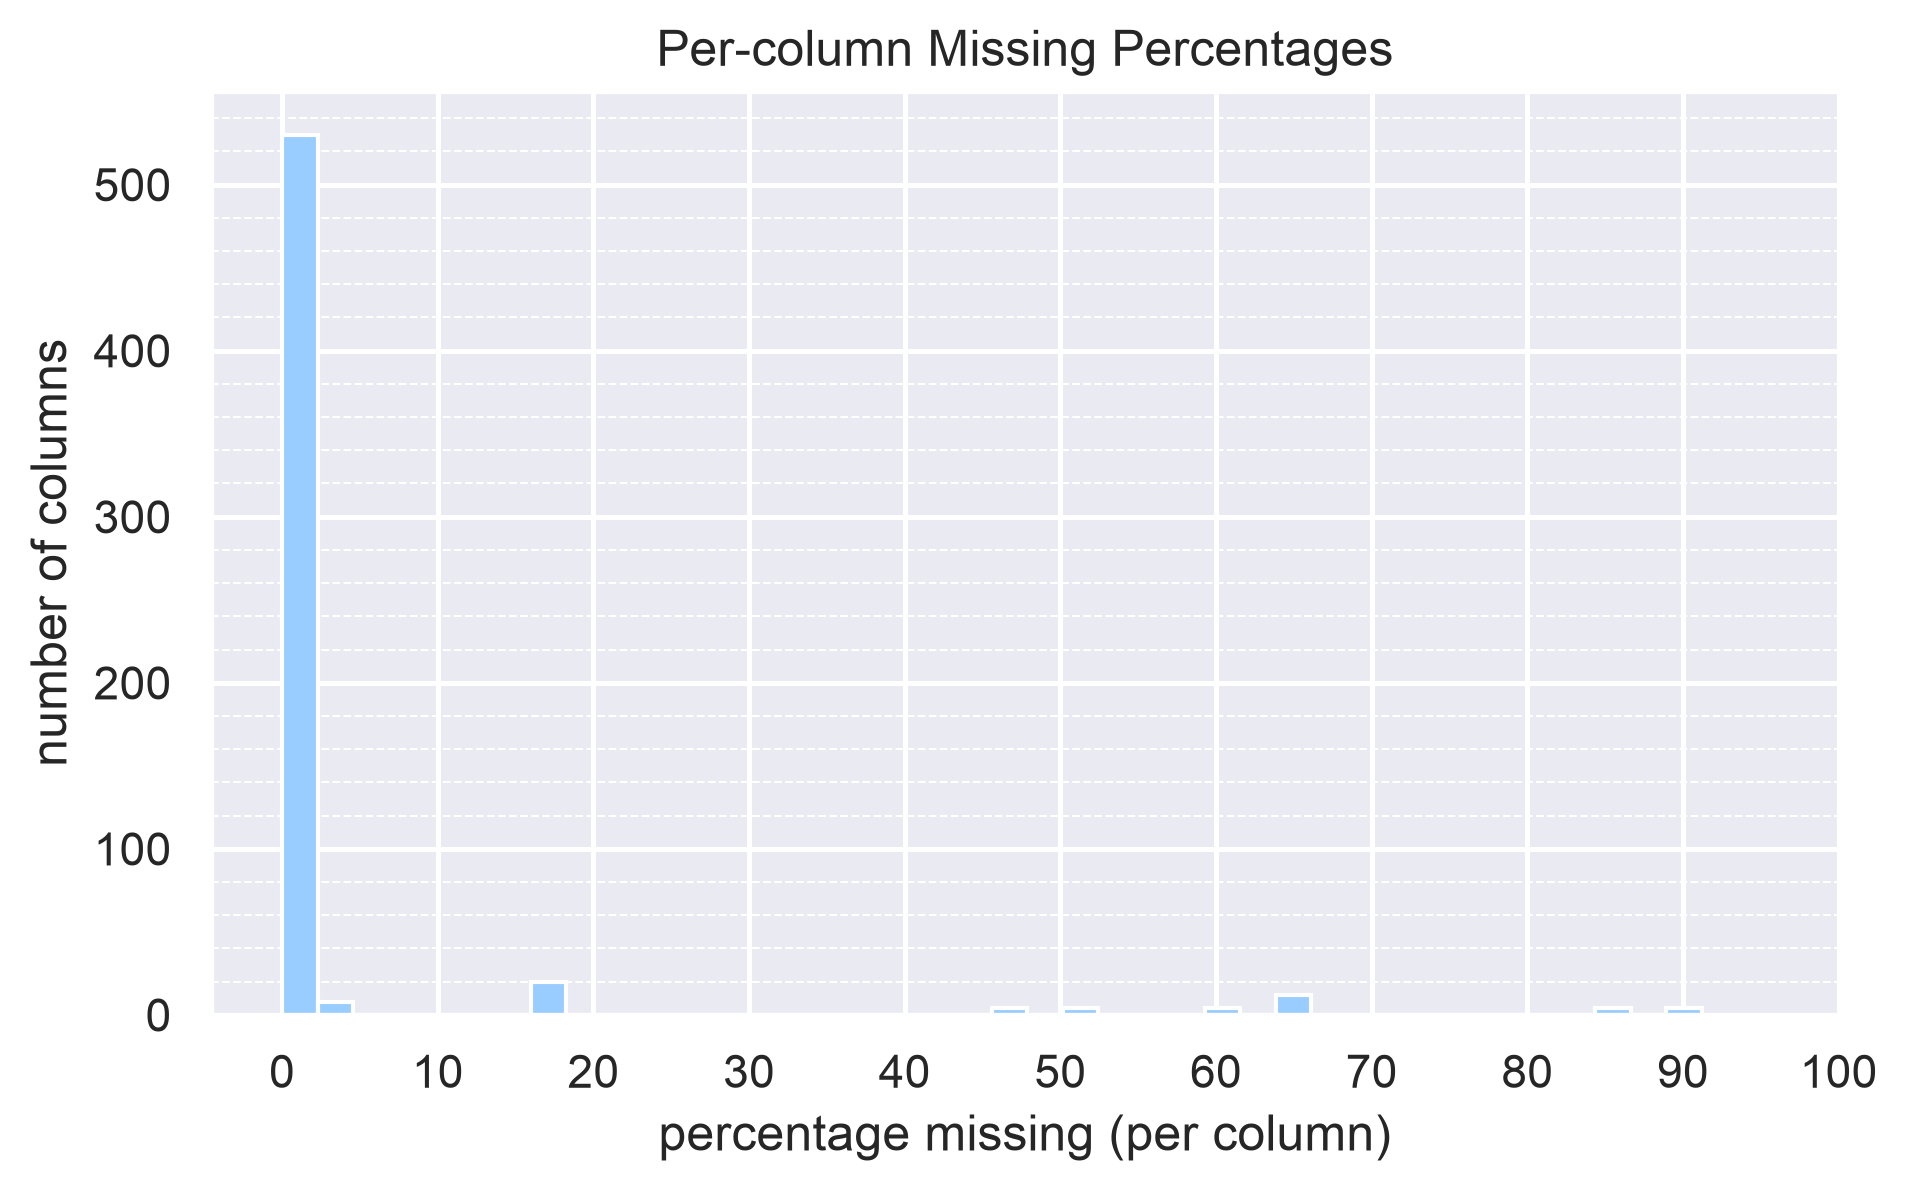

In [22]:
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(7, 4), dpi=300)
ax.hist(missing_frac*100, bins=40, color='#99ccff') 
ax.set_xticks(np.arange(0, 105, 10))
ax.minorticks_on()
ax.grid(which='major', color='white', linewidth=1.2)
ax.grid(which='minor', axis='y', color='white', linestyle='--', linewidth=0.5)
ax.set_xlabel('percentage missing (per column)')
ax.set_ylabel('number of columns')
ax.set_title('Per-column Missing Percentages')

plt.show()

Most columns are near complete. For these we can fill the gaps.
There is only a small group of columns that are missing more than half of their data, we can drop these columns since it's only 4.75% of the overall number of sensors, and they carry little usable information.
**However** before dropping them completely, it is worth checking (on the training set) if the missingness pattern of the column relates to the label at all.

## Constant / zero-variance columns

In [5]:
# columns with a single unique value (ignoring NaN) carry no information
nunique = df[sensor_cols].nunique(dropna=True)
constant_cols = nunique[nunique <= 1].index.tolist()

print(f'constant (<=1 unique value) columns: {len(constant_cols)} ({len(constant_cols)/len(sensor_cols):.2%})')
constant_cols[:20]

constant (<=1 unique value) columns: 116 (19.66%)


['sensor_5',
 'sensor_13',
 'sensor_42',
 'sensor_49',
 'sensor_52',
 'sensor_69',
 'sensor_97',
 'sensor_141',
 'sensor_149',
 'sensor_178',
 'sensor_179',
 'sensor_186',
 'sensor_189',
 'sensor_190',
 'sensor_191',
 'sensor_192',
 'sensor_193',
 'sensor_194',
 'sensor_226',
 'sensor_229']

These columns carry no discriminative info and they asre safe to drop (in the training split)
- need to check for the overlap of constant columns and columns with a lot of missing data

## Timestamp span

In [6]:
print(df['timestamp'].min(), '->', df['timestamp'].max())
print('duration:', df['timestamp'].max() - df['timestamp'].min())
print(df['timestamp'].is_monotonic_increasing)

2008-07-19 11:55:00 -> 2008-10-17 06:07:00
duration: 89 days 18:12:00
True


## Failure distribution across time

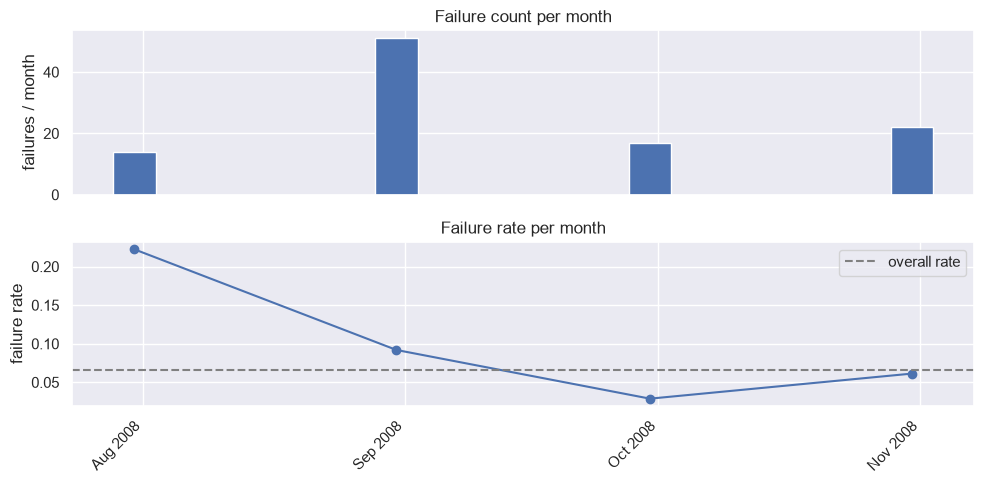

In [23]:
monthly = df.set_index("timestamp")["fail"].resample("ME").agg(["sum", "count", "mean"])

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# top: how many failures each week
ax[0].bar(monthly.index, monthly["sum"], width=5)
ax[0].set_ylabel("failures / month")
ax[0].set_title("Failure count per month")

# bottom: failure rate each week
ax[1].plot(monthly.index, monthly["mean"], marker="o")
ax[1].axhline(df["fail"].mean(), ls="--", color="grey", label="overall rate")
ax[1].set_ylabel("failure rate")
ax[1].set_title("Failure rate per month")
ax[1].legend()
ax[1].xaxis.set_major_locator(mdates.MonthLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


Failure rates drop over time, so we shouldn't really split the dataset based on time (bc the failure rates would not be balanced)